# Bagging - Bootstrapping + AGGregation
### based on wisdom of crowd
Two step algo 
1. Bootstrapping - A technique to draw samples from given data randomly 
    - taking out subset from our data and train our base model
2. Aggregation - outputs of all the models for a datapoint is taken into consideration 

*we can either have same algortihm over different subsets of data or same subset of data over different models*

- Algortihms that have high varience , low bias such as decisiontrees(max_depth=None) , KNN, SVM are made as base models

In [358]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
df = load_iris(as_frame=True).frame
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
112,6.8,3.0,5.5,2.1,2
68,6.2,2.2,4.5,1.5,1
76,6.8,2.8,4.8,1.4,1
92,5.8,2.6,4.0,1.2,1
59,5.2,2.7,3.9,1.4,1


In [359]:
df = df[df['target'] != 0][['sepal width (cm)','petal length (cm)','target']]
df.sample(5)

,sepal width (cm),petal length (cm),target
76,2.8,4.8,1
117,3.8,6.7,2
95,3.0,4.2,1
96,2.9,4.2,1
93,2.3,3.3,1


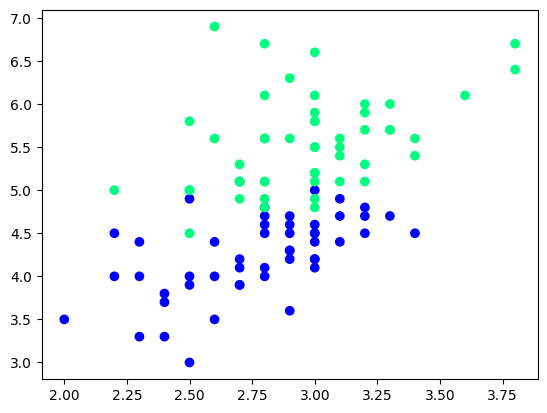

In [360]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['target'],cmap='winter')

In [361]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal width (cm),petal length (cm),target
55,2.8,4.5,1
101,2.7,5.1,2
82,2.7,3.9,1
56,3.3,4.7,1
70,3.2,4.8,1
102,3.0,5.9,2
68,2.2,4.5,1
96,2.9,4.2,1
65,3.1,4.4,1
105,3.0,6.6,2


In [362]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [363]:
df_train

,sepal width (cm),petal length (cm),target
104,3.0,5.8,2
57,2.4,3.3,1
55,2.8,4.5,1
133,2.8,5.1,2
123,2.7,4.9,2
118,2.6,6.9,2
65,3.1,4.4,1
86,3.1,4.7,1
100,3.3,6.0,2
64,2.9,3.6,1


In [364]:
df_val

,sepal width (cm),petal length (cm),target
62,2.2,4.0,1
147,3.0,5.2,2
114,2.8,5.1,2
76,2.8,4.8,1
75,3.0,4.4,1


In [365]:
df_test

,sepal width (cm),petal length (cm),target
68,2.2,4.5,1
143,3.2,5.9,2
98,2.5,3.0,1
72,2.5,4.9,1
87,2.3,4.4,1


In [366]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

## 1. Bagging 
- from your original dataset of N samples, you draw B new datasets by sampling with replacement. 
- Each bootstrap set is the same size as the original but contains duplicates, meaning roughly 37% of the original rows are left out of each sample (these become useful "out-of-bag" samples for validation).

In [367]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),target
57,2.4,3.3,1
57,2.4,3.3,1
65,3.1,4.4,1
118,2.6,6.9,2
64,2.9,3.6,1
123,2.7,4.9,2
104,3.0,5.8,2
123,2.7,4.9,2


In [368]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [369]:
dt_bag1 = DecisionTreeClassifier()

In [370]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

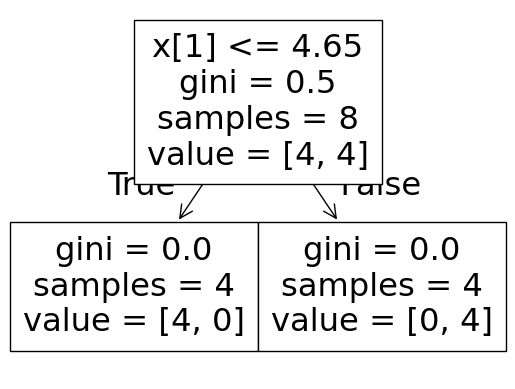

0.8


/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


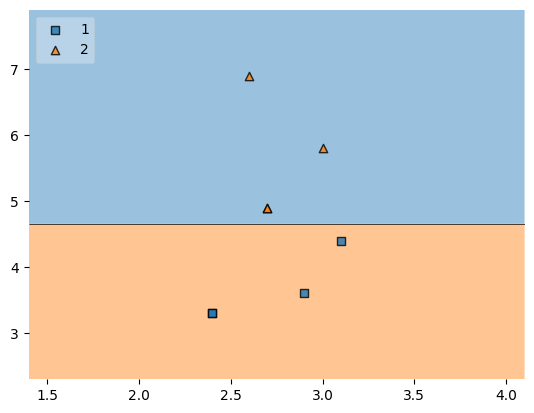

In [371]:
evaluate(dt_bag1,X,y)

In [372]:
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),target
104,3.0,5.8,2
65,3.1,4.4,1
65,3.1,4.4,1
65,3.1,4.4,1
65,3.1,4.4,1
86,3.1,4.7,1
55,2.8,4.5,1
55,2.8,4.5,1


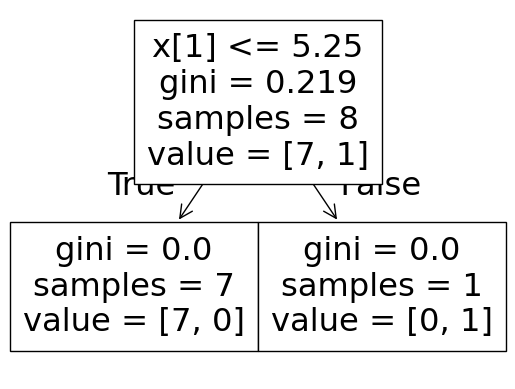

0.6


/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


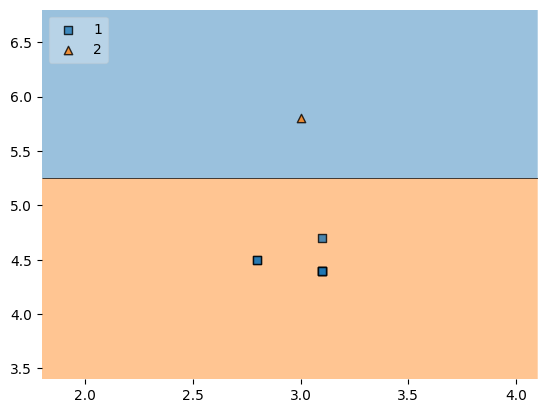

In [373]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [374]:
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),target
86,3.1,4.7,1
57,2.4,3.3,1
104,3.0,5.8,2
104,3.0,5.8,2
65,3.1,4.4,1
123,2.7,4.9,2
64,2.9,3.6,1
64,2.9,3.6,1


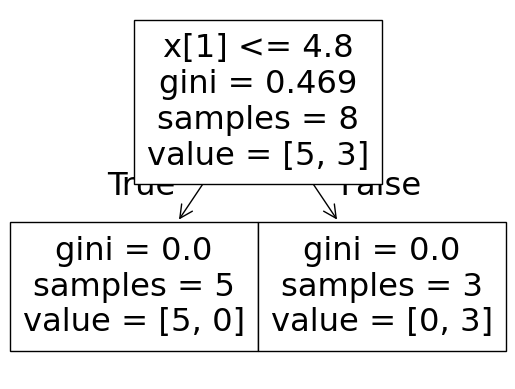

0.8


/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


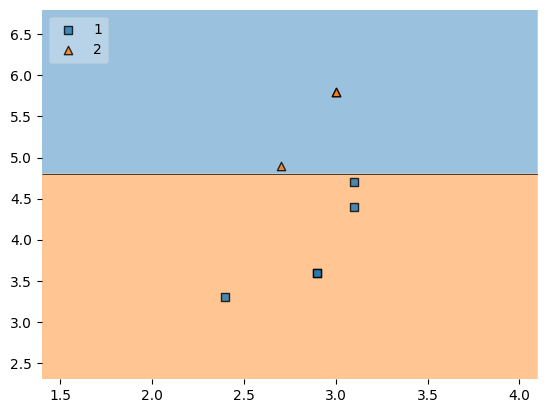

In [375]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [376]:
df_test

,sepal width (cm),petal length (cm),target
68,2.2,4.5,1
143,3.2,5.9,2
98,2.5,3.0,1
72,2.5,4.9,1
87,2.3,4.4,1


In [378]:
print("Predictor 1",dt_bag1.predict(np.array([2.5,4.9]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.5,4.9]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.5,4.9]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [2]


/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/moksh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Conclusion
- as we can see the our crowd(collection of models) was able to produce more accurate results on test data point thus its proven practically that there varience is reduced as compared to before 
- all these models were earlier high varience low bias but now they are low bias and low varience 

there are different types of bagging which i will cover in next notebooks , just making a checklist here
- Pasting : row sampling without replacement
- Random subspace : column based sampling (different feature for each model)
- random patches : Both column and row based sampling